# Definindo Bibliotecas

In [31]:
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

print("✓ Bibliotecas importadas com sucesso!")
print(f"MediaPipe versão: {mp.__version__}")
print(f"OpenCV versão: {cv2.__version__}")

✓ Bibliotecas importadas com sucesso!
MediaPipe versão: 0.10.33
OpenCV versão: 4.13.0


# Selecionando frames do video que serão analisados

In [32]:
def load_video_frames(video_path, frame_indices=None):
    """
    Carrega frames específicos de um vídeo.
    
    Args:
        video_path: Caminho do vídeo
        frame_indices: Lista com índices dos frames desejados. 
                      Se None, usa 6 frames distribuídos uniformemente
    Returns:
        list: Lista de frames (imagens)
    """
    video = cv2.VideoCapture(video_path)
    
    if not video.isOpened():
        raise ValueError(f"Não foi possível abrir o vídeo: {video_path}")
    
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Total de frames no vídeo: {total_frames}")
    
    # Se não especificar frames, distribui 6 uniformemente
    if frame_indices is None:
        frame_indices = np.linspace(0, total_frames - 1, 6, dtype=int).tolist()
    
    frames = []
    for idx in frame_indices:
        video.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = video.read()
        if ret:
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frames.append(frame_rgb)
            print(f"✓ Frame {idx} carregado")
        else:
            print(f"✗ Erro ao carregar frame {idx}")
    
    video.release()
    return frames

def display_frames(frames, title="Frames do Vídeo"):
    """
    Exibe frames em uma grade 2x3 usando matplotlib
    """
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    for idx, (ax, frame) in enumerate(zip(axes.flat, frames)):
        ax.imshow(frame)
        ax.set_title(f"Frame {idx + 1}")
        ax.axis('off')
    
    # Oculta subplots vazios se houver menos de 6 frames
    for idx in range(len(frames), 6):
        axes.flat[idx].axis('off')
    
    plt.tight_layout()
    plt.show()


Total de frames no vídeo: 1037
✓ Frame 3 carregado
✓ Frame 30 carregado
✓ Frame 60 carregado
✓ Frame 90 carregado
✓ Frame 120 carregado
✓ Frame 150 carregado


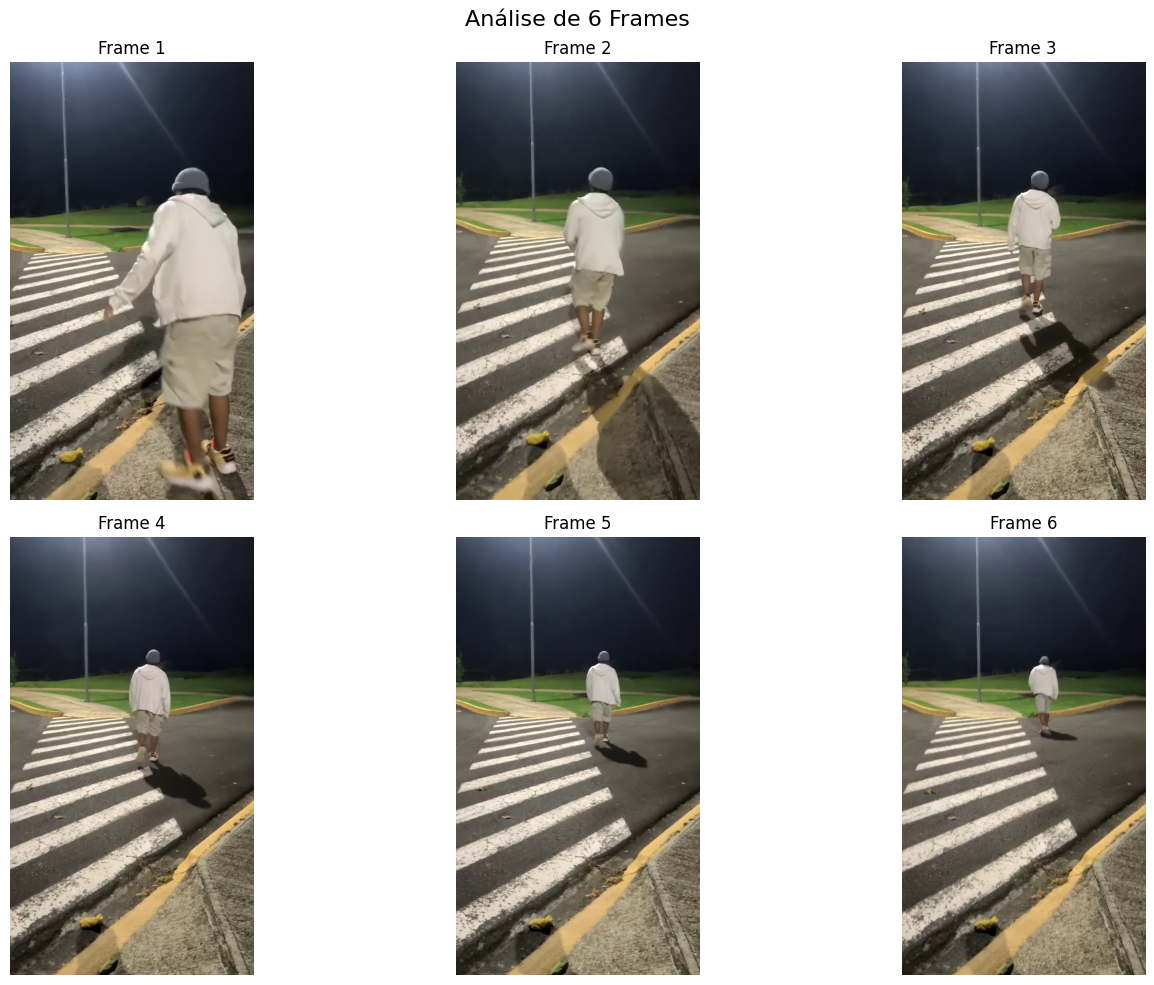

In [33]:
video_path = "gym_videos/video_rodrigo_andando.mp4"
frames = load_video_frames(video_path, frame_indices=[3, 30, 60, 90, 120, 150])  # Exemplo de frames específicos
display_frames(frames, "Análise de 6 Frames")

(np.float64(-0.5), np.float64(479.5), np.float64(863.5), np.float64(-0.5))

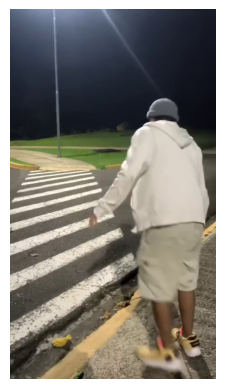

In [78]:
plt.imshow(frames[0])
plt.axis('off')

# Configurando mediapipe

In [34]:
# Setup do MediaPipe Pose Landmarker
model_path = 'models/pose_landmarker_lite.task'

# Para melhor qualidade (mais lento mas preciso)
options = PoseLandmarkerOptions(
    base_options=BaseOptions(model_asset_path='models/pose_landmarker_heavy.task'),
    running_mode=VisionRunningMode.IMAGE,
    min_pose_detection_confidence=0.6,
    min_pose_presence_confidence=0.6,
    num_poses=1,
    output_segmentation_masks=True
)

# Criar instância do PoseLandmarker
landmarker = PoseLandmarker.create_from_options(options)

print("✓ MediaPipe Pose Landmarker inicializado com sucesso!")
print(f"  Modelo: {model_path}")
print(f"  Modo: Image")

✓ MediaPipe Pose Landmarker inicializado com sucesso!
  Modelo: models/pose_landmarker_lite.task
  Modo: Image


In [35]:
def analyze_frame(frame):
    """
    Analisa um frame usando o MediaPipe Pose Landmarker e retorna os resultados.
    
    Args:
        frame: Imagem RGB a ser analisada
    Returns:
        pose_landmarks: Lista de landmarks detectados
    """
    # Converter frame para MediaPipe Image
    image = mp.Image(image_format=mp.ImageFormat.SRGB, 
                    data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    
    # Executar pose detection
    pose_landmarker_result = landmarker.detect(image)
    
    return pose_landmarker_result.pose_landmarks

list_landmarks = []
for idx, frame in enumerate(frames):
    landmarks = analyze_frame(frame)
    list_landmarks.append(landmarks)
list_landmarks[0][0][0]

NormalizedLandmark(x=0.7254098653793335, y=0.30573296546936035, z=0.3370192348957062, visibility=0.990179181098938, presence=0.9990131855010986, name=None)

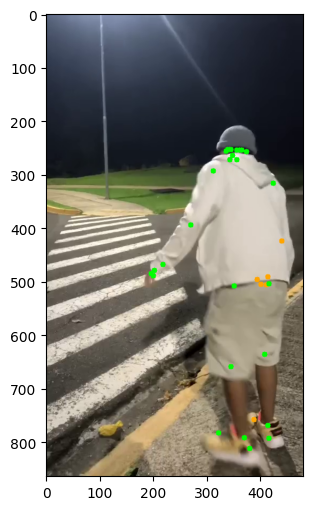

In [36]:
# Desenhando os landmarks no primeiro frame
def draw_landmarks_on_frame(frame, landmarks):
    """
    Desenha os landmarks detectados em um frame.
    
    Args:
        frame: Imagem RGB onde os landmarks serão desenhados
        landmarks: Lista de landmarks a serem desenhados
    Returns:
        frame_with_landmarks: Imagem com os landmarks desenhados
    """
    frame_with_landmarks = frame.copy()
    
    for idx, landmark in enumerate(landmarks):
        x = int(landmark.x * frame.shape[1])
        y = int(landmark.y * frame.shape[0])
        visibility = landmark.visibility
        presence = landmark.presence
        
        # Cor baseada na visibilidade e presença
        if visibility > 0.5 and presence > 0.5:
            color = (0, 255, 0)  # Verde para landmarks confiáveis
        elif visibility > 0.5:
            color = (255, 0, 0)  # Vermelho para landmarks visíveis mas não presentes
        elif presence > 0.5:
            color = (255, 165, 0)  # Laranja para landmarks presentes mas não visíveis
        else:
            color = (255, 0, 0)  # Vermelho para landmarks não confiáveis
        
        cv2.circle(frame_with_landmarks, (x, y), 5, color, -1)
    
    return frame_with_landmarks
# Desenhar e exibir o primeiro frame com landmarks
frame_with_landmarks = draw_landmarks_on_frame(frames[0], list_landmarks[0][0])
plt.figure(figsize=(8, 6))
plt.imshow(frame_with_landmarks)

In [37]:
POSE_CONNECTIONS = [
    # Cabeça
    (0, 1), (1, 2), (2, 3),
    (3, 7), (0, 4), (4, 5), (5, 6), (6, 8),
    (9, 10),
    
    # Braço esquerdo
    (11, 13), (13, 15),
    (15, 17), (17, 19), (19, 21),
    
    # Braço direito
    (12, 14), (14, 16),
    (16, 18), (18, 20), (20, 22),
    
    # Tronco
    (11, 12),
    (11, 23), (12, 24),
    (23, 24),
    
    # Perna esquerda
    (23, 25), (25, 27), (27, 29), (29, 31),
    
    # Perna direita
    (24, 26), (26, 28), (28, 30), (30, 32)
]

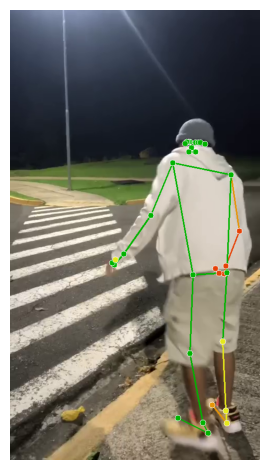

In [75]:
# Função auxiliar para colorir baseado em visibilidade
def get_color_by_visibility(visibility):
    """
    Retorna cor BGR baseada no valor de visibilidade (0 a 1)
    Verde (alta) -> Amarelo -> Laranja -> Vermelho (baixa)
    """
    if visibility > 0.8:
        return (0, 180, 0)  # Verde (alta visibilidade)
    elif visibility > 0.6:
        return (229, 232, 26)  # Amarelo (boa visibilidade)
    elif visibility > 0.4:
        return (230, 148, 7)  # Laranja (média visibilidade)
    else:
        return (230, 66, 7)  # Vermelho (baixa visibilidade)

# Desenhar os landmarks do primeiro frame com conexões (esqueleto em 2D)
def draw_skeleton_2d(frame, landmarks):
    """
    Desenha um esqueleto 2D conectando os landmarks no frame
    Colore baseado na visibilidade de cada ponto
    """
    frame_skeleton = frame.copy()
    
    # Desenhar as conexões (bones) primeiro
    for connection in POSE_CONNECTIONS:
        start_idx, end_idx = connection
        
        if start_idx < len(landmarks) and end_idx < len(landmarks):
            start_lm = landmarks[start_idx]
            end_lm = landmarks[end_idx]
            
            x1 = int(start_lm.x * frame.shape[1])
            y1 = int(start_lm.y * frame.shape[0])
            x2 = int(end_lm.x * frame.shape[1])
            y2 = int(end_lm.y * frame.shape[0])
            
            # Cor baseada na visibilidade média dos dois pontos
            avg_visibility = (start_lm.visibility + end_lm.visibility) / 2
            color = get_color_by_visibility(avg_visibility)
            
            # Desenhar linha conectando os pontos
            cv2.line(frame_skeleton, (x1, y1), (x2, y2), color, 2)
    
    # Depois desenhar os pontos (landmarks)
    for idx, landmark in enumerate(landmarks):
        x = int(landmark.x * frame.shape[1])
        y = int(landmark.y * frame.shape[0])
        
        # Cor baseada na visibilidade do ponto
        color = get_color_by_visibility(landmark.visibility)
        
        cv2.circle(frame_skeleton, (x, y), 6, color, -1)
        # Adicionar borda branca para melhor visualização
        cv2.circle(frame_skeleton, (x, y), 6, (255, 255, 255), 1)
    
    return frame_skeleton

# Desenhar e exibir o esqueleto do primeiro frame
frame_skeleton = draw_skeleton_2d(frames[0], list_landmarks[0][0])

plt.imshow(frame_skeleton)
plt.axis('off')

plt.tight_layout()
plt.show()

In [79]:
import plotly.graph_objects as go

LANDMARK_NAMES = [
    'Nose', 'Left Eye Inner', 'Left Eye', 'Left Eye Outer', 'Right Eye Inner', 'Right Eye', 'Right Eye Outer',
    'Left Ear', 'Right Ear', 'Mouth Left', 'Mouth Right',
    'Left Shoulder', 'Right Shoulder', 'Left Elbow', 'Right Elbow', 'Left Wrist', 'Right Wrist',
    'Left Pinky', 'Right Pinky', 'Left Index', 'Right Index', 'Left Thumb', 'Right Thumb',
    'Left Hip', 'Right Hip', 'Left Knee', 'Right Knee', 'Left Ankle', 'Right Ankle',
    'Left Heel', 'Right Heel', 'Left Foot Index', 'Right Foot Index'
]

def get_color_plotly_by_visibility(visibility):
    """
    Retorna cor Plotly baseada no valor de visibilidade (0 a 1)
    Verde (alta) -> Amarelo -> Laranja -> Vermelho (baixa)
    """
    if visibility > 0.8:
        return 'green'
    elif visibility > 0.6:
        return 'gold'
    elif visibility > 0.4:
        return 'orange'
    else:
        return 'red'

def create_3d_skeleton_frontal(world_landmarks, frame_number=0):
    """
    Cria visualização 3D com vista frontal clara - boneco em pé
    Colore baseado na visibilidade
    """
    if not world_landmarks or len(world_landmarks) == 0:
        print(f"✗ Frame {frame_number}: Nenhum landmark 3D encontrado!")
        return
    
    landmarks_3d = world_landmarks[0]
    
    if len(landmarks_3d) < 33:
        print(f"✗ Frame {frame_number}: Apenas {len(landmarks_3d)}/33 landmarks detectados")
        return
    
    # Extrair coordenadas
    x_coords = [lm.x for lm in landmarks_3d]
    y_coords = [lm.y for lm in landmarks_3d]
    z_coords = [lm.z for lm in landmarks_3d]
    
    # Encontrar o chão (altura mínima em Y)
    floor_height = min(y_coords) - 0.1
    
    # Criar figura Plotly
    fig = go.Figure()
    
    # Definir limites para o chão (base quadrada)
    margin = 0.4
    x_min, x_max = min(x_coords) - margin, max(x_coords) + margin
    z_min, z_max = min(z_coords) - margin, max(z_coords) + margin
    
    # Desenhar o chão - MESH preenchido
    fig.add_trace(go.Mesh3d(
        x=[x_min, x_max, x_max, x_min],
        y=[floor_height, floor_height, floor_height, floor_height],
        z=[z_min, z_min, z_max, z_max],
        i=[0, 0],
        j=[1, 2],
        k=[2, 3],
        color='lightgray',
        opacity=0.7,
        name='Chão',
        showlegend=True
    ))
    
    # Bordas do chão
    floor_x = [x_min, x_max, x_max, x_min, x_min]
    floor_z = [z_min, z_min, z_max, z_max, z_min]
    floor_y = [floor_height] * 5
    
    fig.add_trace(go.Scatter3d(
        x=floor_x, y=floor_y, z=floor_z,
        mode='lines',
        line=dict(color='darkgray', width=4),
        name='Bordas',
        hoverinfo='skip',
        showlegend=False
    ))
    
    # Cores para diferentes landmarks baseado em visibilidade
    colors = [get_color_plotly_by_visibility(lm.visibility) for lm in landmarks_3d]
    
    # Adicionar os pontos com cores baseadas em visibilidade
    fig.add_trace(go.Scatter3d(
        x=x_coords, y=y_coords, z=z_coords,
        mode='markers+text',
        marker=dict(size=10, color=colors, opacity=1.0, line=dict(width=2, color='white')),
        text=[f"V: {landmarks_3d[i].visibility:.2f}" for i in range(len(landmarks_3d))],
        textposition="top center",
        textfont=dict(size=8, color='black'),
        hoverinfo='text',
        name='Landmarks'
    ))
    
    # Adicionar as conexões (bones) com espessura maior
    for connection in POSE_CONNECTIONS:
        start_idx, end_idx = connection
        
        if start_idx < len(landmarks_3d) and end_idx < len(landmarks_3d):
            start_lm = landmarks_3d[start_idx]
            end_lm = landmarks_3d[end_idx]
            
            x = [start_lm.x, end_lm.x]
            y = [start_lm.y, end_lm.y]
            z = [start_lm.z, end_lm.z]
            
            # Cor baseada na visibilidade média dos dois pontos
            avg_visibility = (start_lm.visibility + end_lm.visibility) / 2
            line_color = get_color_plotly_by_visibility(avg_visibility)
            
            fig.add_trace(go.Scatter3d(
                x=x, y=y, z=z,
                mode='lines',
                line=dict(color=line_color, width=8),
                hoverinfo='skip',
                showlegend=False
            ))
    
    # Configurar layout - VISTA FRONTAL pura
    fig.update_layout(
        title=f'<b>Boneco em Pé - Frame {frame_number}</b><br><sub>Verde: Alta visibilidade | Amarelo: Boa | Laranja: Média | Vermelho: Baixa</sub>',
        scene=dict(
            xaxis=dict(title='Esquerda ← → Direita', backgroundcolor='rgba(220, 220, 220, 0.5)'),
            yaxis=dict(title='Altura', backgroundcolor='rgba(220, 220, 220, 0.5)'),
            zaxis=dict(title='Profundidade', backgroundcolor='rgba(220, 220, 220, 0.5)'),
            camera=dict(
                eye=dict(x=0, y=-1.8, z=0),  # Câmera frontal
                center=dict(x=0, y=0, z=0),
                up=dict(x=0, y=1, z=0)  # Y apontando para cima
            ),
            aspectmode='data'
        ),
        width=900,
        height=1000,
        showlegend=True,
        hovermode='closest',
        template='plotly_white'
    )
    
    fig.show()
    print(f"✓ Frame {frame_number} - Vista Frontal")


complete_results = []
for idx, frame in enumerate(frames):
    image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame)
    result = landmarker.detect(image)
    complete_results.append(result)
    
# Executar
print("Criando vista frontal do boneco em pé...\n")
for idx, result in enumerate(complete_results):
    if result.pose_world_landmarks:
        create_3d_skeleton_frontal(result.pose_world_landmarks, frame_number=idx)
    else:
        print(f"✗ Frame {idx} - Nenhuma pose detectada")
    break

Criando vista frontal do boneco em pé...



✓ Frame 0 - Vista Frontal
